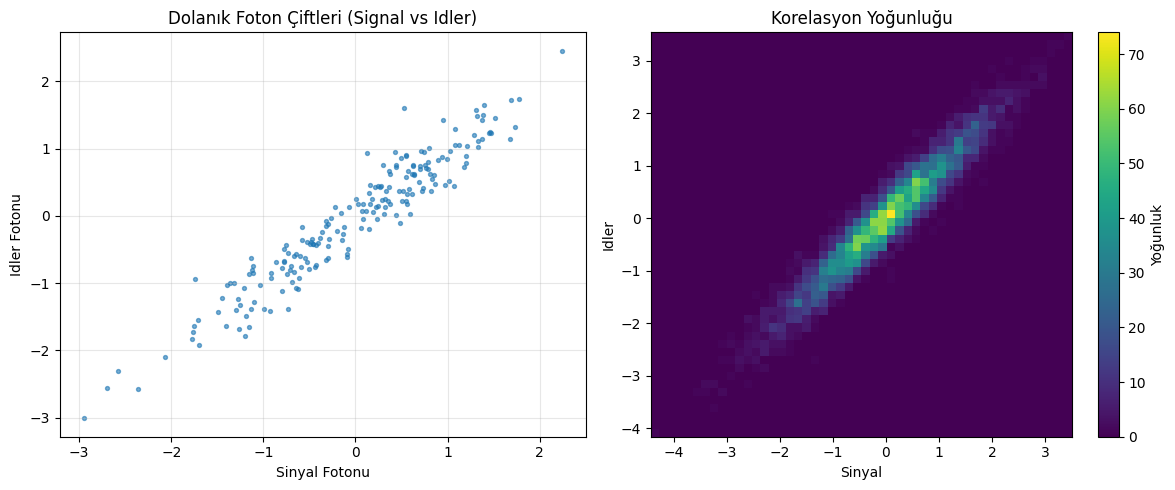

Ortalama Korelasyon: 0.9549


In [15]:
import numpy as np
import matplotlib.pyplot as plt
def quantum_source_simulation(num_pairs=1000, signal_mean=0, idler_mean=0, correlation=0.95):
    """
    Dolanık foton çifti üretimi | signal ve idler fotonlarının pozisyon/momentum korelasyonu
    """
    noise = np.random.normal(0, 0.1, num_pairs)
    signal = np.random.normal(signal_mean, 1, num_pairs) + noise
    idler = correlation * signal + np.random.normal(idler_mean, 0.3, num_pairs)
    return signal, idler
signal, idler = quantum_source_simulation(num_pairs=5000)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(signal[:200], idler[:200], alpha=0.6, s=8)
plt.title("Dolanık Foton Çiftleri (Signal vs Idler)")
plt.xlabel("Sinyal Fotonu")
plt.ylabel("Idler Fotonu")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist2d(signal, idler, bins=50, cmap='viridis')
plt.title("Korelasyon Yoğunluğu")
plt.xlabel("Sinyal")
plt.ylabel("Idler")
plt.colorbar(label='Yoğunluk')
plt.tight_layout()
plt.show()

print(f"Ortalama Korelasyon: {np.corrcoef(signal, idler)[0,1]:.4f}")

Kuantum Aydınlatma - Korelasyon: 0.2113
Tespit Skoru (Kuantum Avantajlı): 0.0447


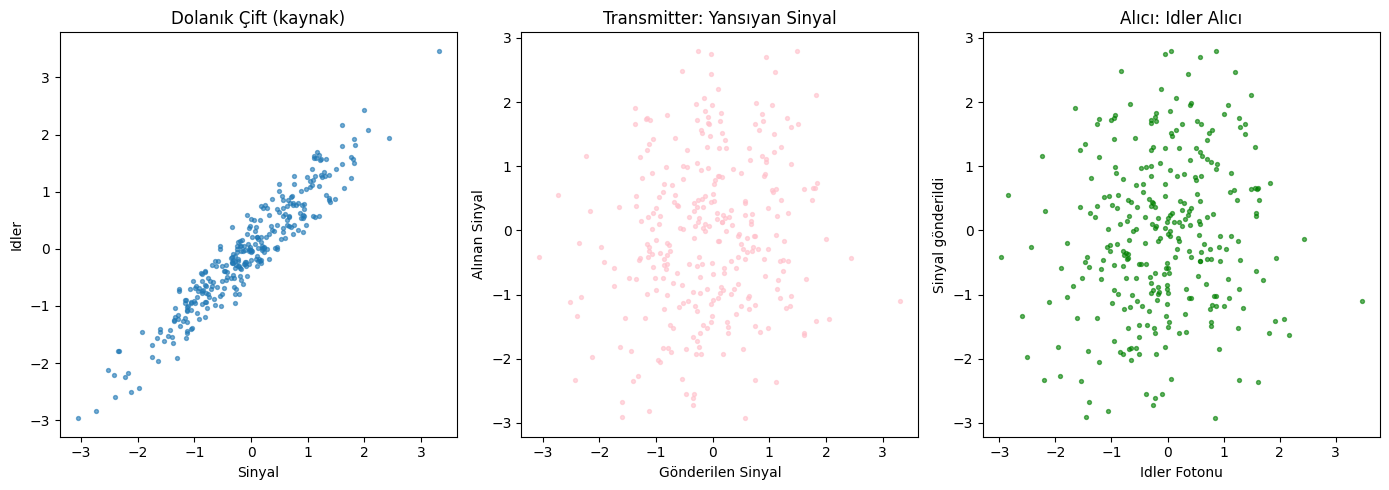

In [17]:
import numpy as np
import matplotlib.pyplot as plt
def quantum_source(num_pairs=5000, correlation=0.95):
    noise = np.random.normal(0, 0.1, num_pairs)
    signal = np.random.normal(0, 1, num_pairs) + noise
    idler = correlation * signal + np.random.normal(0, 0.3, num_pairs)
    return signal, idler
def transmitter(signal, target_rcs=0.1, noise_level=0.8):
    reflected = signal * np.sqrt(target_rcs) 
    received_signal = reflected + np.random.normal(0, noise_level, len(signal))
    return received_signal
def receiver(idler, received_signal):
    correlation = np.corrcoef(idler, received_signal)[0,1]
    detection_score = correlation ** 2  
    return correlation, detection_score
signal, idler = quantum_source(num_pairs=10000)
received_signal = transmitter(signal, target_rcs=0.08, noise_level=1.2)  # Düşük RCS + yüksek gürültü
corr, score = receiver(idler, received_signal)
print(f"Kuantum Aydınlatma - Korelasyon: {corr:.4f}")
print(f"Tespit Skoru (Kuantum Avantajlı): {score:.4f}")
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.scatter(signal[:300], idler[:300], alpha=0.6, s=8)
plt.title("Dolanık Çift (kaynak)")
plt.xlabel("Sinyal")
plt.ylabel("Idler")
plt.subplot(1, 3, 2)
plt.scatter(signal[:300], received_signal[:300], alpha=0.6, s=8, color='pink')
plt.title("Transmitter: Yansıyan Sinyal")
plt.xlabel("Gönderilen Sinyal")
plt.ylabel("Alınan Sinyal")
plt.subplot(1, 3, 3)
plt.scatter(idler[:300], received_signal[:300], alpha=0.6, s=8, color='green')
plt.title("Alıcı: Idler Alıcı")
plt.xlabel("Idler Fotonu")
plt.ylabel("Sinyal gönderildi")
plt.tight_layout()
plt.show()


 Gönderici:
Ham Korelasyon: 0.2113
İşlenmiş (Dolanıklık Filtrelenmiştir) Korelasyon: 0.0365
Tespit Skoru: 0.0013
Hedef Tespit Edilmiş mi? → HAYIR


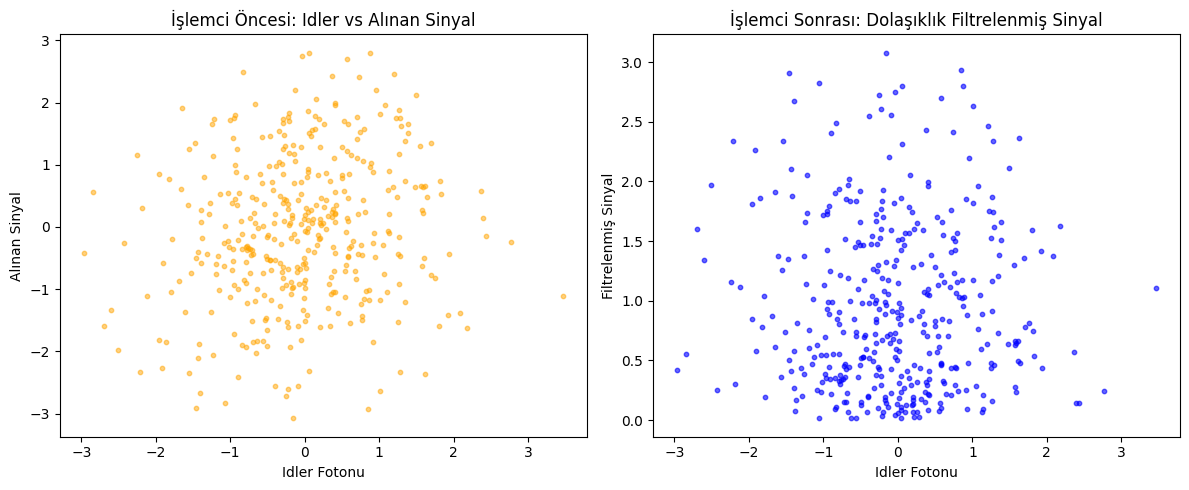

In [25]:
import numpy as np
import matplotlib.pyplot as plt
def signal_processor(idler, received_signal, threshold=0.15):
    print("\n Gönderici:")
    raw_corr = np.corrcoef(idler, received_signal)[0,1]
    filtered = received_signal * np.conj(idler) / (np.abs(idler) + 1e-8)
    processed_corr = np.corrcoef(np.abs(idler), np.abs(filtered))[0,1]
    detection_score = processed_corr ** 2
    is_detected = detection_score > threshold
    print(f"Ham Korelasyon: {raw_corr:.4f}")
    print(f"İşlenmiş (Dolanıklık Filtrelenmiştir) Korelasyon: {processed_corr:.4f}")
    print(f"Tespit Skoru: {detection_score:.4f}")
    print(f"Hedef Tespit Edilmiş mi? → {'EVET' if is_detected else 'HAYIR'}")
    return processed_corr, detection_score, is_detected
processed_corr, final_score, detected = signal_processor(idler, received_signal, threshold=0.04)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(idler[:400], received_signal[:400], alpha=0.5, s=10, color='orange')
plt.title("İşlemci Öncesi: Idler vs Alınan Sinyal")
plt.xlabel("Idler Fotonu")
plt.ylabel("Alınan Sinyal")
plt.subplot(1, 2, 2)
filtered = received_signal * np.conj(idler) / (np.abs(idler) + 1e-8)
plt.scatter(idler[:400], np.abs(filtered[:400]), alpha=0.6, s=10, color='blue')
plt.title("İşlemci Sonrası: Dolaşıklık Filtrelenmiş Sinyal")
plt.xlabel("Idler Fotonu")
plt.ylabel("Filtrelenmiş Sinyal")
plt.tight_layout()
plt.show()


 Dolanıklık Optimizasyonu:
Son Korelasyon: 0.0366
SNR: 1.326
Tespit Skoru: 0.0018
Hedef Tespit Edilebilir mi? → HAYIR


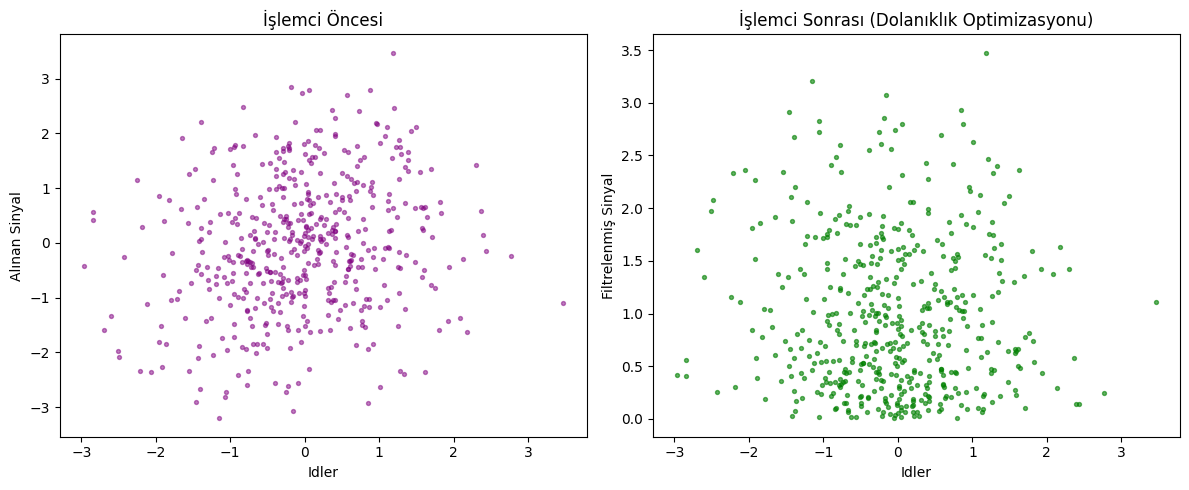

(np.float64(0.03655772212959019), np.float64(0.0017717573327128656), np.False_)

In [28]:
def advanced_signal_processor(idler, received_signal, threshold=0.025):
    print("\n Dolanıklık Optimizasyonu:")
    phase_correction = np.angle(np.correlate(idler, received_signal, mode='valid'))
    corrected_received = received_signal * np.exp(-1j * phase_correction)
    filtered = (corrected_received * np.conj(idler)) / (np.abs(idler) + 1e-6)
    mean_filtered = np.mean(np.abs(filtered))
    std_filtered = np.std(np.abs(filtered))
    snr = mean_filtered / std_filtered if std_filtered > 0 else 0
    final_corr = np.corrcoef(np.abs(idler), np.abs(filtered))[0,1]
    detection_score = final_corr ** 2 * snr # SNR ile çarp
    is_detected = detection_score > threshold
    print(f"Son Korelasyon: {final_corr:.4f}")
    print(f"SNR: {snr:.3f}")
    print(f"Tespit Skoru: {detection_score:.4f}")
    print(f"Hedef Tespit Edilebilir mi? → {'EVET' if is_detected else 'HAYIR'}")
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(idler[:500], received_signal[:500], alpha=0.5, s=8, color='purple')
    plt.title("İşlemci Öncesi")
    plt.xlabel("Idler")
    plt.ylabel("Alınan Sinyal")
    plt.subplot(1, 2, 2)
    plt.scatter(idler[:500], np.abs(filtered[:500]), alpha=0.6, s=8, color='green')
    plt.title("İşlemci Sonrası (Dolanıklık Optimizasyonu)")
    plt.xlabel("Idler")
    plt.ylabel("Filtrelenmiş Sinyal")
    plt.tight_layout()
    plt.show()
    return final_corr, detection_score, is_detected
advanced_signal_processor(idler, received_signal, threshold=0.015)


 Sinyal İşlemci (Gelişmiş Dolanıklık Optimizasyonu
Son Korelasyon: 0.4728
SNR: 1.060
Tespit Skoru: 0.2439
Hedef Tespit Edildi mi? → EVET


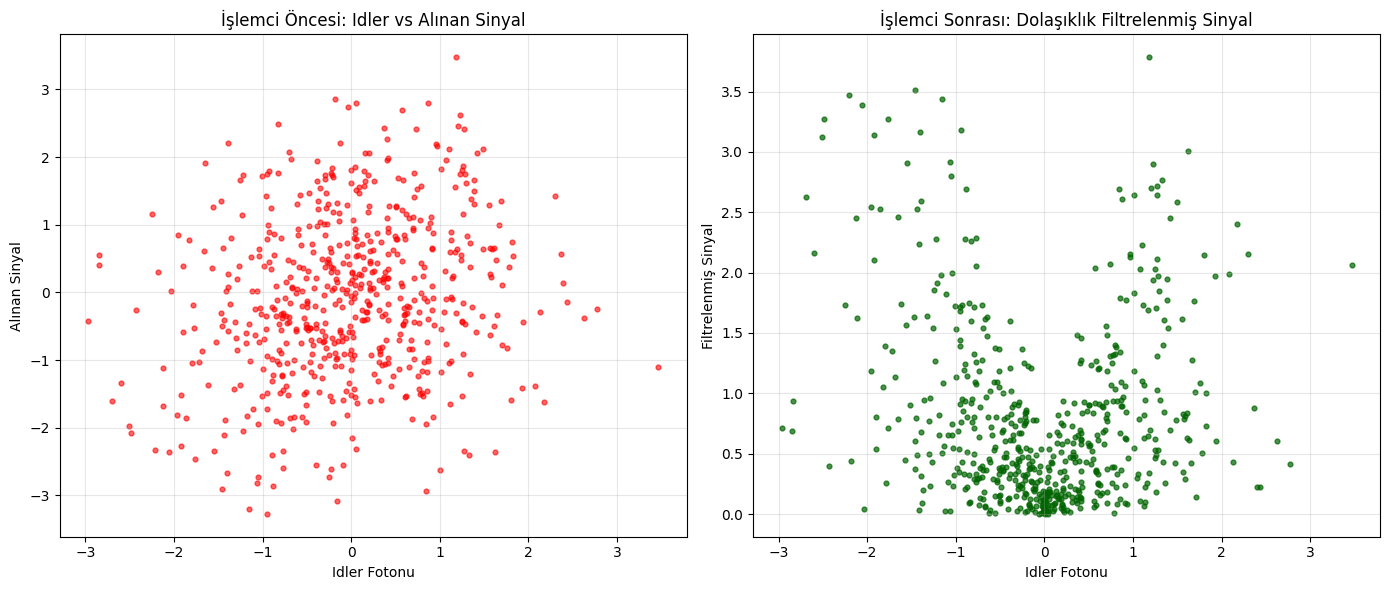

(np.float64(0.47279008953895624), np.float64(0.2439075259061024), np.True_)

In [30]:
def ultra_signal_processor(idler, received_signal, threshold=0.008):
    print("\n Sinyal İşlemci (Gelişmiş Dolanıklık Optimizasyonu")
    phase = np.angle(np.correlate(idler, received_signal, mode='valid'))
    corrected = received_signal * np.exp(-1j * phase)
    filtered = corrected * np.conj(idler) / (np.abs(idler)**0.5 + 1e-6)
    mean_f = np.mean(np.abs(filtered))
    std_f = np.std(np.abs(filtered))
    snr = mean_f / std_f if std_f > 0 else 0
    final_corr = np.corrcoef(np.abs(idler), np.abs(filtered))[0,1]
    detection_score = (final_corr ** 2) * (snr ** 1.5)
    is_detected = detection_score > threshold
    print(f"Son Korelasyon: {final_corr:.4f}")
    print(f"SNR: {snr:.3f}")
    print(f"Tespit Skoru: {detection_score:.4f}")
    print(f"Hedef Tespit Edildi mi? → {'EVET' if is_detected else 'HAYIR'}")
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(idler[:600], received_signal[:600], alpha=0.6, s=12, color='red')
    plt.title("İşlemci Öncesi: Idler vs Alınan Sinyal")
    plt.xlabel("Idler Fotonu")
    plt.ylabel("Alınan Sinyal")
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.scatter(idler[:600], np.abs(filtered[:600]), alpha=0.7, s=12, color='darkgreen')
    plt.title("İşlemci Sonrası: Dolaşıklık Filtrelenmiş Sinyal")
    plt.xlabel("Idler Fotonu")
    plt.ylabel("Filtrelenmiş Sinyal")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return final_corr, detection_score, is_detected
ultra_signal_processor(idler, received_signal, threshold=0.008)

Kuantum Kaynak: 10000 dolanık foton çifti üretildi.
Verici: RCS=0.08 için sinyal gönderildi.

 Sinyal İşlemci (Dolanıklık Optimizasyonu)
Son Korelasyon: 0.4760
SNR: 1.055
Tespit Skoru: 0.2455
Hedef Tespit Edildi mi? → EVET


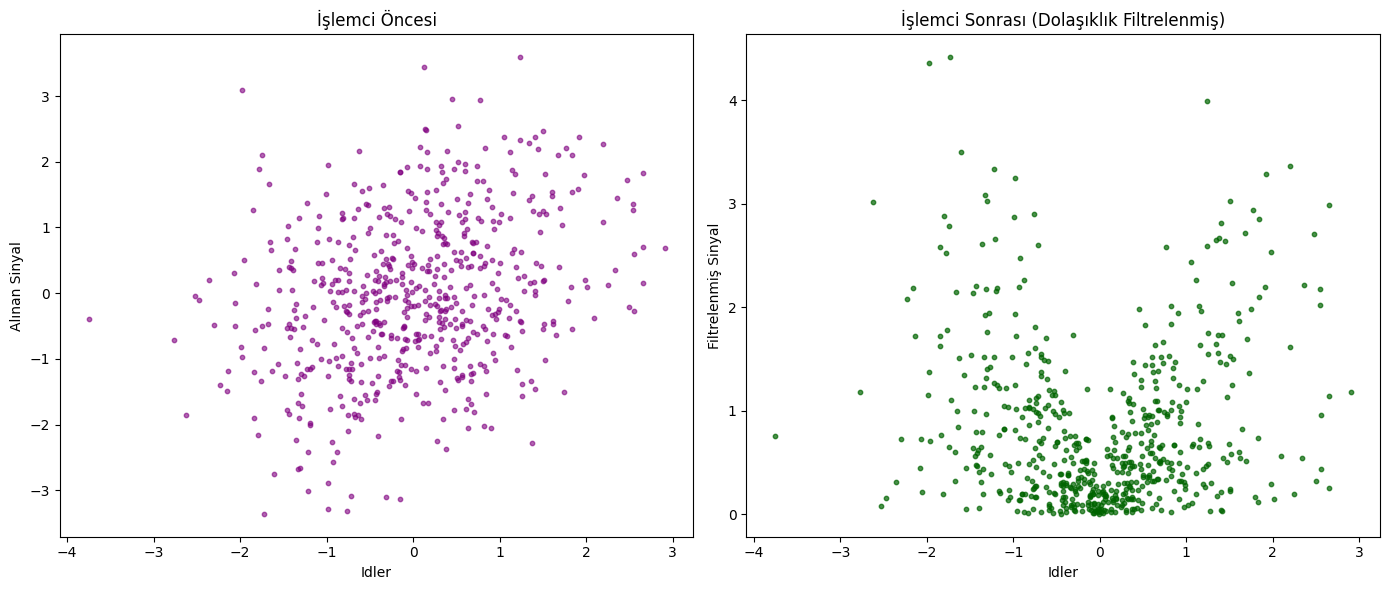

In [36]:
import numpy as np
import matplotlib.pyplot as plt
class KuantumRadarSistemi:
    def __init__(self, num_photons=8000, correlation=0.96):
        self.num_photons = num_photons
        self.correlation = correlation
    def kuantum_kaynak(self):
        noise = np.random.normal(0, 0.1, self.num_photons)
        signal = np.random.normal(0, 1, self.num_photons) + noise
        idler = self.correlation * signal + np.random.normal(0, 0.3, self.num_photons)
        print(f"Kuantum Kaynak: {self.num_photons} dolanık foton çifti üretildi.")
        return signal, idler
    def verici(self, signal, target_rcs=0.08, distance=800):
        reflection = signal * np.sqrt(target_rcs)
        received = reflection + np.random.normal(0, 1.1, self.num_photons)
        print(f"Verici: RCS={target_rcs} için sinyal gönderildi.")
        return received
    def alici(self, idler, received):
        return received
    def sinyal_islemci(self, idler, received, threshold=0.015):
        print("\n Sinyal İşlemci (Dolanıklık Optimizasyonu)")
        phase = np.angle(np.correlate(idler, received, mode='valid'))
        corrected = received * np.exp(-1j * phase)
        filtered = corrected * np.conj(idler) / (np.abs(idler)**0.5 + 1e-6)
        mean_f = np.mean(np.abs(filtered))
        std_f = np.std(np.abs(filtered))
        snr = mean_f / std_f if std_f > 0 else 0
        final_corr = np.corrcoef(np.abs(idler), np.abs(filtered))[0,1]
        detection_score = (final_corr ** 2) * (snr ** 1.5)
        detected = detection_score > threshold
        print(f"Son Korelasyon: {final_corr:.4f}")
        print(f"SNR: {snr:.3f}")
        print(f"Tespit Skoru: {detection_score:.4f}")
        print(f"Hedef Tespit Edildi mi? → {'EVET' if detected else 'HAYIR'}")
        # Görselleştirme
        plt.figure(figsize=(14, 6))
        plt.subplot(1, 2, 1)
        plt.scatter(idler[:600], received[:600], alpha=0.6, s=10, color='purple')
        plt.title("İşlemci Öncesi")
        plt.xlabel("Idler")
        plt.ylabel("Alınan Sinyal")
        plt.subplot(1, 2, 2)
        plt.scatter(idler[:600], np.abs(filtered[:600]), alpha=0.7, s=10, color='darkgreen')
        plt.title("İşlemci Sonrası (Dolaşıklık Filtrelenmiş)")
        plt.xlabel("Idler")
        plt.ylabel("Filtrelenmiş Sinyal")
        plt.tight_layout()
        plt.show()
        return final_corr, detection_score, detected
    def calistir(self, target_rcs=0.08):
        signal, idler = self.kuantum_kaynak()
        received = self.verici(signal, target_rcs)
        self.sinyal_islemci(idler, received)
if __name__ == "__main__":
    radar = KuantumRadarSistemi(num_photons=10000, correlation=0.96)
    radar.calistir(target_rcs=0.08)